In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


Before exploring the dataset, the following questions were considered:

1. What is the shape of the dataset?
2. Are there any missing values?
3. Which variables are numerical and categorical?
4. Which features are strongly correlated?
5. Are there any outliers?
6. What trends can be observed?
7. Are there any anomalies in the dataset?

In [ ]:
df = pd.read_csv("netflix_titles.csv")

In [9]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [10]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (8807, 12)


Netflix has 8,807 titles in the dataset, including Movies and TV Shows.

In [11]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [13]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [14]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [17]:
# Remove rows with missing values in important columns
df = df.dropna(subset=['date_added', 'rating', 'duration'])

# Check again
df.isnull().sum()

show_id            0
type               0
title              0
director        2621
cast             825
country          829
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
description        0
dtype: int64

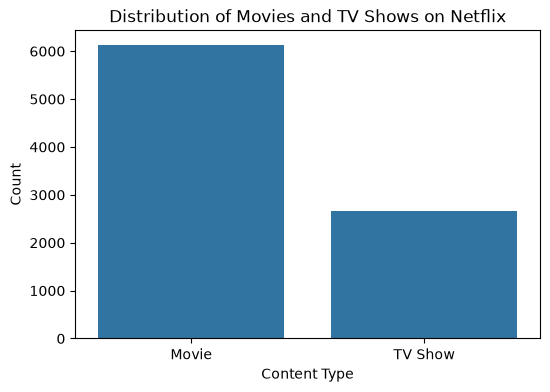

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x='type', data=df)

plt.title('Distribution of Movies and TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

Movies significantly outnumber TV Shows on Netflix, indicating that Netflix's content library is primarily focused on movies.

In [19]:
country_df = df.dropna(subset=['country'])

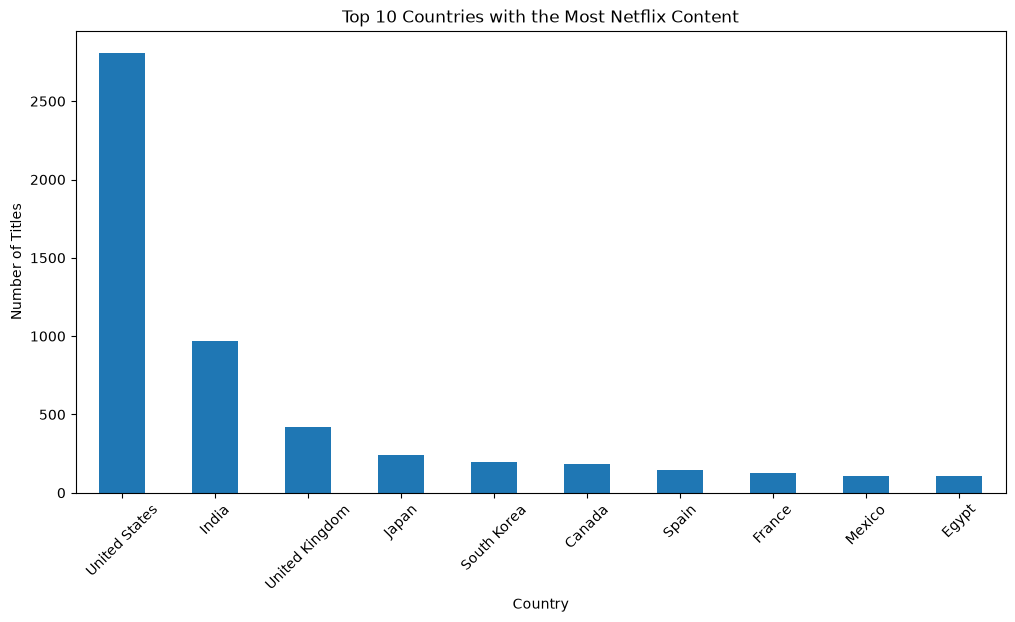

In [20]:
plt.figure(figsize=(12,6))

country_df['country'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Countries with the Most Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)
plt.show()

The United States contributes the largest number of titles to Netflix, followed by several other countries. This indicates that the U.S. is the dominant content producer in Netflix's catalog.

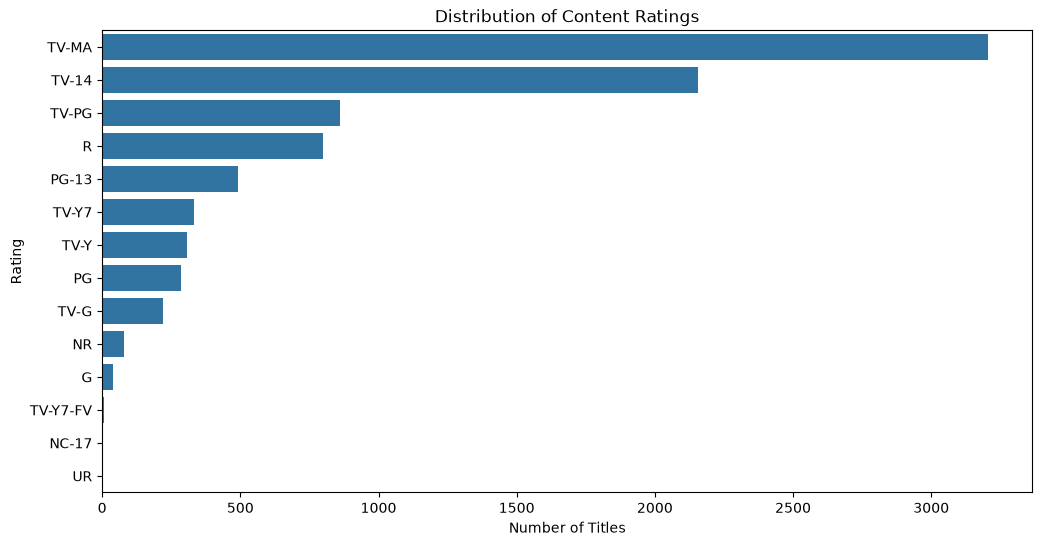

In [21]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)

plt.title('Distribution of Content Ratings')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')

plt.show()

TV-MA is the most common content rating on Netflix, followed by TV-14 and TV-PG. This suggests that Netflix primarily offers content targeted toward mature and teenage audiences.

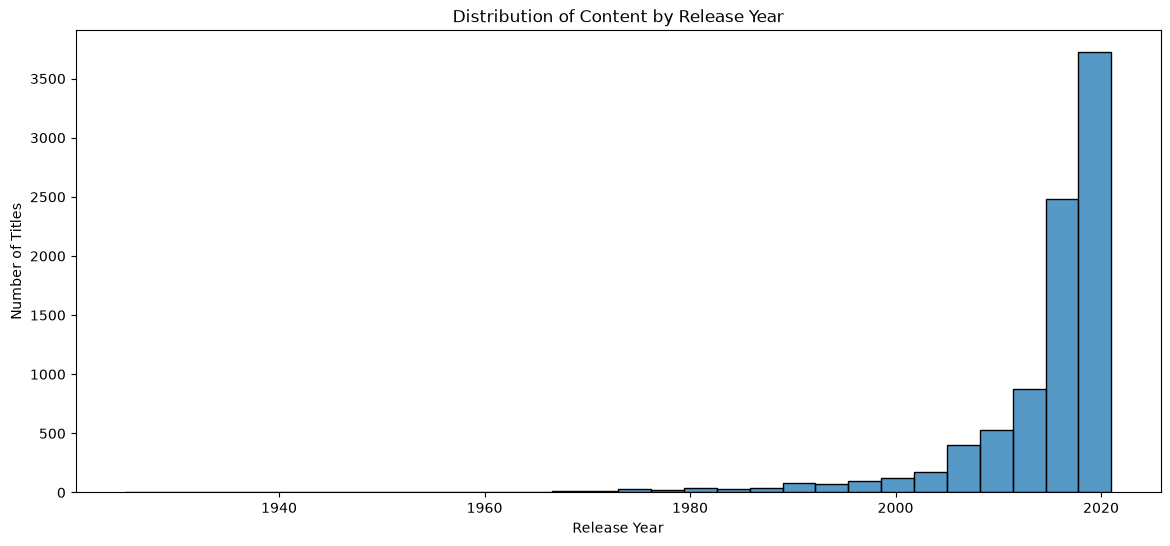

In [22]:
plt.figure(figsize=(14,6))

sns.histplot(df['release_year'], bins=30)

plt.title('Distribution of Content by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

The number of Netflix titles has increased significantly over the years, with the 2010s showing the highest number of releases. This reflects Netflix's rapid expansion and investment in content during that decade.

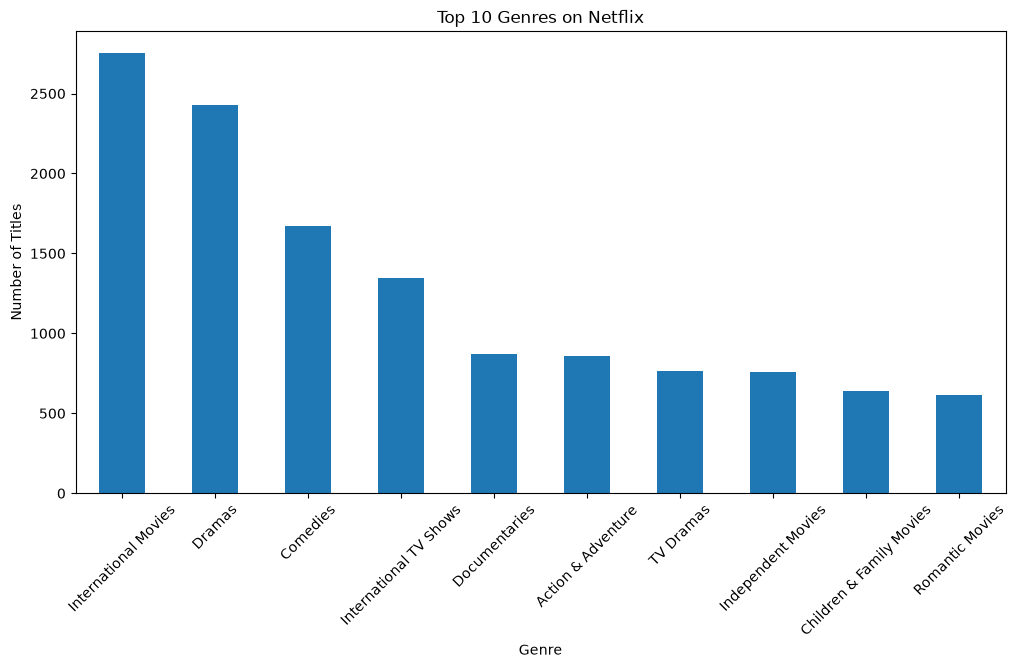

In [23]:
# Split multiple genres into separate rows
genres = df['listed_in'].str.split(', ').explode()

# Plot the top 10 genres
plt.figure(figsize=(12,6))

genres.value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)
plt.show()

International Movies is the most common genre on Netflix, indicating that Netflix has a strong focus on providing diverse content from around the world. This is followed by genres such as dramas, comedies, and international TV shows.


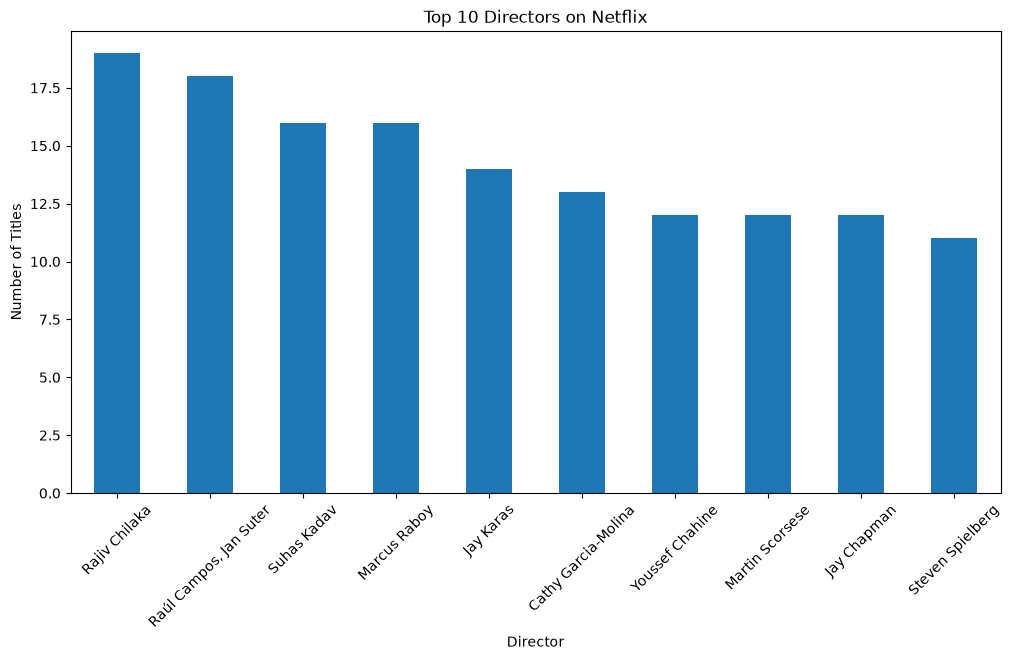

In [24]:
# Remove missing director values
director_df = df.dropna(subset=['director'])

plt.figure(figsize=(12,6))

director_df['director'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Directors on Netflix')
plt.xlabel('Director')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)
plt.show()

Rajiv Chilaka has directed the highest number of titles available in this Netflix dataset, reflecting a strong presence of animated children's content.


In [30]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [31]:
df['year_added'] = df['date_added'].dt.year

In [32]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added'],
      dtype='str')

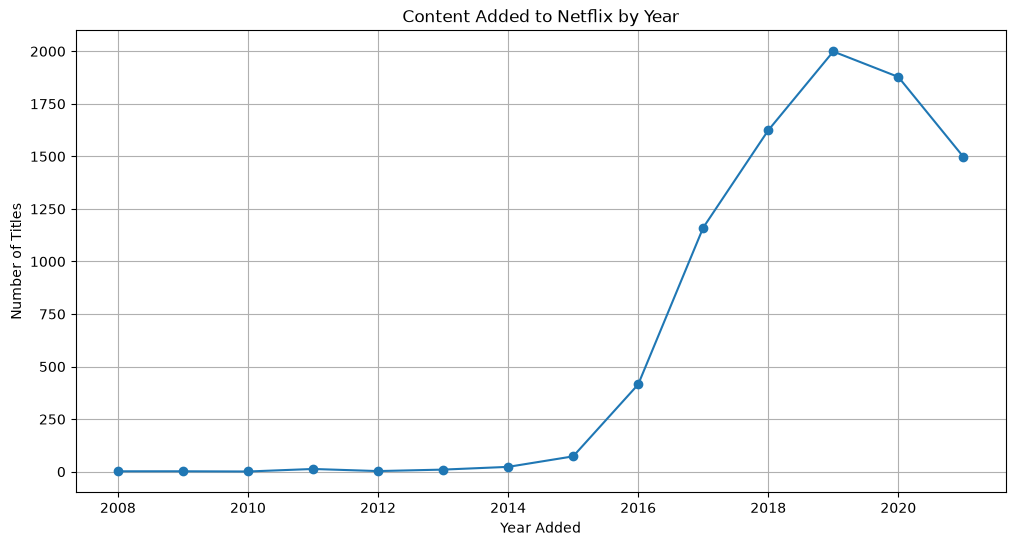

In [33]:
plt.figure(figsize=(12,6))

df['year_added'].value_counts().sort_index().plot(kind='line', marker='o')

plt.title('Content Added to Netflix by Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.grid(True)

plt.show()

Netflix added the highest number of titles in 2019. The number of additions increased steadily over the years, peaked in 2019, and then declined slightly afterward.

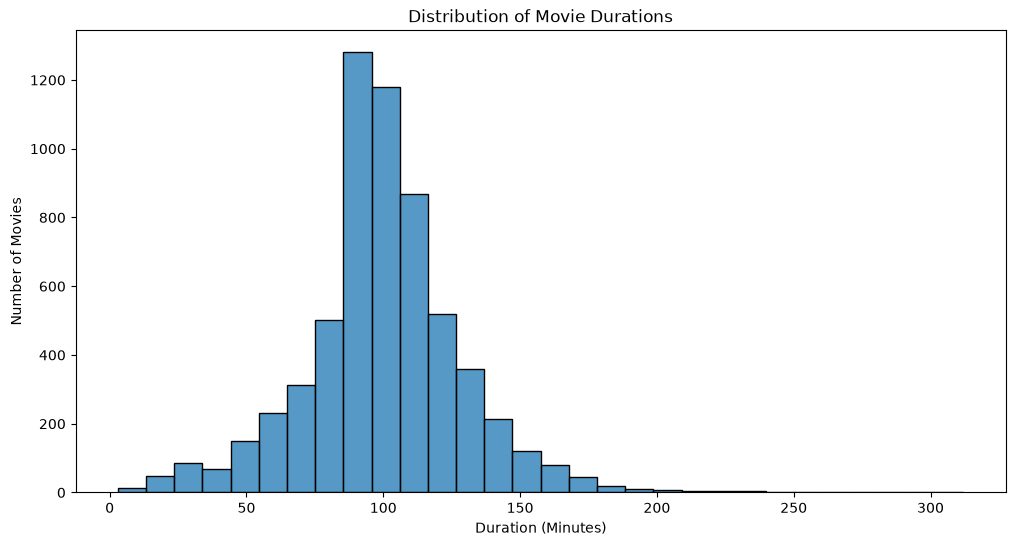

In [34]:
# Filter only movies
movies = df[df['type'] == 'Movie'].copy()

# Convert duration to integer (minutes)
movies['duration'] = movies['duration'].str.replace(' min', '', regex=False)
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

# Plot histogram
plt.figure(figsize=(12,6))

sns.histplot(movies['duration'].dropna(), bins=30)

plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')

plt.show()

Most Netflix movies have a duration between 80 and 120 minutes.

This Exploratory Data Analysis (EDA) project examined the Netflix Movies and TV Shows dataset to identify patterns and trends in the platform's content library.
 The analysis revealed that movies dominate the catalog, the United States contributes the largest share of content, TV-MA is the most frequent content rating, and International Movies are the most common genre. Additionally, Netflix experienced significant growth in content additions, reaching its peak in 2019. These insights demonstrate how EDA helps uncover meaningful information from raw data and supports data-driven decision-making.